# A1: Investigating Bias in Code Smell Detection Models

**Student:** [Enter your name]  
**Course:** Software Testing  
**Study basis:** Arcelli et al., *Comparing and experimenting machine learning techniques for code smell detection* (2015).

This notebook analyzes the **Data Class** (class-level) and **Feature Envy** (method-level) binary classification datasets. It examines data quality, class balance, metric distributions, metric correlations, and project-held-out model evaluation. All numerical claims are calculated from the loaded files.

**Data source:** the files were downloaded from the official [ESSeRE Lab MLCSD page](https://essere.disco.unimib.it/machine-learning-for-code-smell-detection/), using its Google Drive link to `binary_class.zip`, and extracted under `data/binary_class/`. The selected CSVs each contain 420 labeled rows (140 positive, 280 negative) and records from 74 projects. The separate `evaluation_dataset.zip` link on that page currently returns HTTP 404, so this notebook uses the related official binary-class release instead; it does not silently claim to have loaded that unavailable archive.

> **Sampling caveat:** the 1:2 class ratio describes these selected samples, not real-world code-smell prevalence. High within-archive performance cannot establish that the learned relationships generalize to different labeling protocols, projects, or populations.

## 1. Reproducibility and data setup

In Google Colab, run the upload cell and select exactly these two CSV files: `data-class.csv` and `feature-envy.csv`. They are inside `binary_class.zip` under `binary_class/`; extract that ZIP on your computer first. You do not need to upload the ZIP or the other four smell datasets. Colab will prompt only when either CSV is missing from the current runtime.

When running locally, the notebook reads the same files from `data/binary_class/`. The analysis uses `is_data_class` and `is_feature_envy` as target columns; labels are booleans (`true` = smelly, `false` = non-smelly). Artifact IDs and names are excluded from predictors, while `project` is retained only to ensure project-disjoint evaluation. The CSV reader handles Feature Envy method signatures that contain commas. Numeric missing values are imputed inside each training pipeline.

In [34]:
from pathlib import Path

try:
    from google.colab import files as colab_files
    IN_COLAB = True
except ImportError:
    colab_files = None
    IN_COLAB = False

required_csvs = ["data-class.csv", "feature-envy.csv"]
if IN_COLAB:
    missing_csvs = [name for name in required_csvs if not Path(name).is_file()]
    if missing_csvs:
        print("Upload these two files from the extracted binary_class folder:")
        print("  data-class.csv")
        print("  feature-envy.csv")
        colab_files.upload()
        missing_csvs = [name for name in required_csvs if not Path(name).is_file()]
        if missing_csvs:
            raise FileNotFoundError(
                "Upload both required CSV files. Still missing: " + ", ".join(missing_csvs)
            )
    DATASET_DIR = Path(".")
    print("Colab upload ready:", ", ".join(required_csvs))
else:
    DATASET_DIR = Path("data") / "binary_class"
    missing_csvs = [str(DATASET_DIR / name) for name in required_csvs if not (DATASET_DIR / name).is_file()]
    if missing_csvs:
        raise FileNotFoundError(
            "Local dataset files not found: " + ", ".join(missing_csvs)
        )
    print("Using local datasets in", DATASET_DIR)

Using local datasets in data\binary_class


In [35]:
%pip install -q pandas numpy matplotlib seaborn scikit-learn scipy openpyxl

import re
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.io import arff
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    ConfusionMatrixDisplay, balanced_accuracy_score, confusion_matrix,
    f1_score, precision_score, recall_score,
)
from sklearn.model_selection import StratifiedGroupKFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

RANDOM_STATE = 42
POSITIVE_CLASS = 1
sns.set_theme(style="whitegrid", context="notebook")

DATASETS = {
    "Data Class": {
        "path": str(DATASET_DIR / "data-class.csv"),
        "target_column": "is_data_class",
        "positive_label": True,
        "negative_label": False,
        "drop_columns": ["IDType", "project", "package", "complextype"],
    },
    "Feature Envy": {
        "path": str(DATASET_DIR / "feature-envy.csv"),
        "target_column": "is_feature_envy",
        "positive_label": True,
        "negative_label": False,
        "drop_columns": ["IDMethod", "project", "package", "complextype", "method"],
    },
}
TEST_SIZE = 0.20
CV_FOLDS = 5
TOP_METRICS_TO_PLOT = 6
CORRELATION_THRESHOLD = 0.85

print("Configured Data Class and Feature Envy datasets. Smelly instances are the positive class.")

Note: you may need to restart the kernel to use updated packages.
Configured Data Class and Feature Envy datasets. Smelly instances are the positive class.


In [36]:
def read_dataset(path):
    path = Path(path).expanduser()
    if not path.is_file():
        raise FileNotFoundError(f"Dataset file not found: {path.resolve()}")
    suffix = path.suffix.lower()
    if suffix == ".csv":
        try:
            return pd.read_csv(path)
        except pd.errors.ParserError:
            return pd.read_csv(path, quotechar="'")
    if suffix in {".xlsx", ".xls"}:
        return pd.read_excel(path)
    if suffix == ".arff":
        records, _ = arff.loadarff(path)
        frame = pd.DataFrame(records)
        for column in frame.select_dtypes(include=["object"]).columns:
            frame[column] = frame[column].map(
                lambda value: value.decode("utf-8") if isinstance(value, bytes) else value
            )
        return frame
    raise ValueError(f"Unsupported file type {suffix!r}; use CSV, Excel, or ARFF.")

def prepare_dataset(name, config):
    required = ("path", "target_column", "positive_label", "negative_label")
    missing_config = [
        key for key in required
        if config.get(key) is None or config.get(key) == ""
    ]
    if missing_config:
        raise ValueError(
            f"Configure {name}: missing {', '.join(missing_config)} in DATASETS."
        )
    frame = read_dataset(config["path"]).copy()
    target = config["target_column"]
    if target not in frame.columns:
        raise KeyError(f"{name}: target {target!r} not found. Columns: {frame.columns.tolist()}")
    frame = frame.loc[frame[target].notna()].copy()
    groups = frame["project"].copy() if "project" in frame.columns else pd.Series(frame.index, index=frame.index)
    frame = frame.drop(columns=[c for c in config.get("drop_columns", []) if c in frame.columns])
    observed = set(frame[target].unique())
    expected = {config["positive_label"], config["negative_label"]}
    if observed != expected:
        raise ValueError(
            f"{name}: labels found {sorted(map(str, observed))}; expected exactly "
            f"{sorted(map(str, expected))}. Check values and filter unrelated labels."
        )
    y = frame.pop(target).map({config["negative_label"]: 0, config["positive_label"]: 1}).astype(int)
    X = frame.apply(pd.to_numeric, errors="coerce")
    all_missing = X.columns[X.isna().all()].tolist()
    if all_missing:
        warnings.warn(f"{name}: dropping non-numeric/all-missing columns: {all_missing}")
        X = X.drop(columns=all_missing)
    if X.empty:
        raise ValueError(f"{name}: no numeric feature columns remain. Check file and drop_columns.")
    constant = X.columns[X.nunique(dropna=True) <= 1].tolist()
    near_constant = []
    for column in X.columns.difference(constant):
        frequencies = X[column].value_counts(normalize=True, dropna=True)
        if not frequencies.empty and frequencies.iloc[0] >= 0.99:
            near_constant.append(column)
    return {
        "raw": frame, "X": X, "y": y, "groups": groups,
        "constant": constant, "near_constant": near_constant, "target": target,
    }

data = {name: prepare_dataset(name, config) for name, config in DATASETS.items()}
print("Loaded datasets:", {name: item['X'].shape for name, item in data.items()})
print("Project groups:", {name: item['groups'].nunique() for name, item in data.items()})

Loaded datasets: {'Data Class': (420, 61), 'Feature Envy': (420, 82)}
Project groups: {'Data Class': 74, 'Feature Envy': 74}


## 2. Dataset overview and class distribution
The target is recoded to `1 = smelly` (positive class) and `0 = non-smelly`. Counts and percentages describe these archive samples, not population prevalence. Duplicate metric/label rows are reported here and excluded from model evaluation; constant and near-constant features are reported but retained unless a later model pipeline requires otherwise.


Data Class: target='is_data_class'; constant features=[]
Near-constant features=[]


,count,percent
is_data_class,,
Non-smelly,280,66.67
Smelly,140,33.33


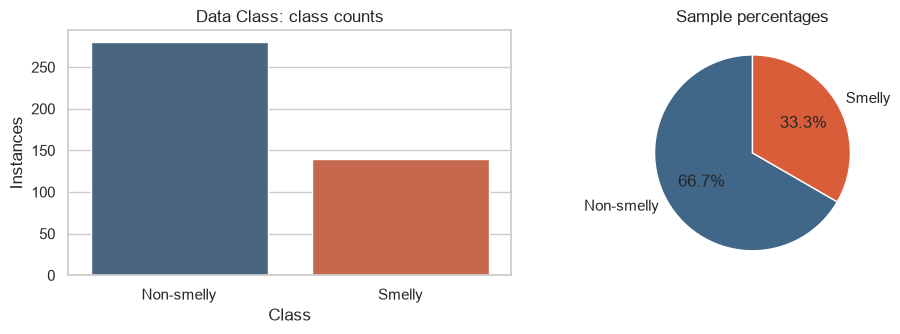

Interpretation: the 1:2 ratio is the composition of this sample; use precision, recall, F1, and balanced accuracy rather than accuracy alone.

Feature Envy: target='is_feature_envy'; constant features=[]
Near-constant features=['isStatic_type']


,count,percent
is_feature_envy,,
Non-smelly,280,66.67
Smelly,140,33.33


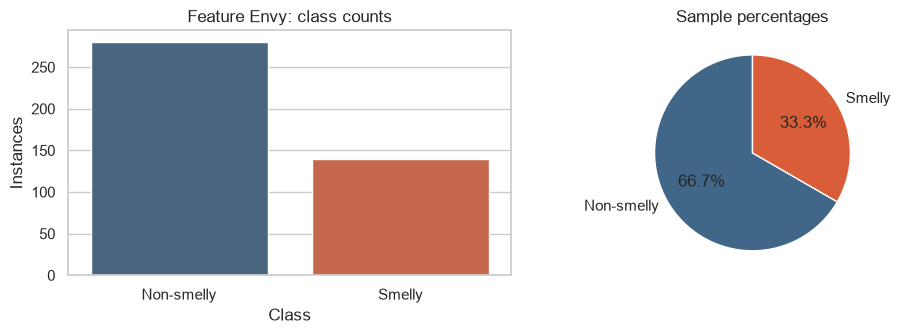

Interpretation: the 1:2 ratio is the composition of this sample; use precision, recall, F1, and balanced accuracy rather than accuracy alone.


,Rows,Numeric features,"Smelly (n, %)","Non-smelly (n, %)",Missing feature cells,Exact duplicate metric/label rows,Constant features detected,Near-constant features (>=99% one value)
Dataset,,,,,,,,
Data Class,420,61,140 (33.3%),280 (66.7%),75,2,0,0
Feature Envy,420,82,140 (33.3%),280 (66.7%),92,13,0,1


In [29]:
overview_rows = []
for name, item in data.items():
    X, y = item["X"], item["y"]
    raw_with_target = pd.concat([X, y.rename(item["target"])], axis=1)
    counts = y.value_counts().reindex([0, 1], fill_value=0)
    percentages = y.value_counts(normalize=True).reindex([0, 1], fill_value=0) * 100
    overview_rows.append({
        "Dataset": name, "Rows": len(X), "Numeric features": X.shape[1],
        "Smelly (n, %)": f"{counts[1]} ({percentages[1]:.1f}%)",
        "Non-smelly (n, %)": f"{counts[0]} ({percentages[0]:.1f}%)",
        "Missing feature cells": int(X.isna().sum().sum()),
        "Exact duplicate metric/label rows": int(raw_with_target.duplicated().sum()),
        "Constant features detected": len(item["constant"]),
        "Near-constant features (>=99% one value)": len(item["near_constant"]),
    })
    print(f"\n{name}: target={item['target']!r}; constant features={item['constant']}")
    print(f"Near-constant features={item['near_constant']}")
    display(pd.DataFrame({"count": counts, "percent": percentages.round(2)}).rename(index={0: "Non-smelly", 1: "Smelly"}))
    fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
    labels = y.map({0: "Non-smelly", 1: "Smelly"})
    sns.countplot(
        x=labels, order=["Non-smelly", "Smelly"], hue=labels, legend=False,
        ax=axes[0], palette={"Non-smelly": "#416788", "Smelly": "#d95d39"},
    )
    axes[0].set(title=f"{name}: class counts", xlabel="Class", ylabel="Instances")
    axes[1].pie(counts.values, labels=["Non-smelly", "Smelly"], autopct="%.1f%%", colors=["#416788", "#d95d39"], startangle=90)
    axes[1].set_title("Sample percentages")
    plt.tight_layout(); plt.show()
    print("Interpretation: the 1:2 ratio is the composition of this sample; use precision, recall, F1, and balanced accuracy rather than accuracy alone.")

overview = pd.DataFrame(overview_rows).set_index("Dataset")
display(overview)

## 3. Software metric distributions
The next cell summarizes numeric metrics by class and visualizes the metrics with the largest standardized mean differences. Histograms and boxplots reveal overlap, skew, and outliers; a standardized effect size is descriptive, not a causal or universal smell threshold. Read each plot before making claims: limited overlap can indicate that labels are closely tied to measured rules or to this sample's selection process.


Data Class: class-wise metric summary (count, mean, median, std, min, max, skew)


WOC_type                                       TCC_type         \
              count   mean median    std  min  max   skew    count   mean   
_class                                                                      
Non-smelly      252  0.652  0.733  0.341  0.0  1.0 -0.604      280  0.518   
Smelly          140  0.135  0.111  0.154  0.0  1.0  2.027      140  0.156   

                   ... WMCNAMM_type             CFNAMM_type                 \
           median  ...          min  max   skew       count    mean median   
_class             ...                                                       
Non-smelly  0.414  ...            1  937  1.961         280  29.421    7.0   
Smelly      0.143  ...            0   18  2.380         140   0.664    0.0   

                                   
               std min  max  skew  
_class                             
Non-smelly  41.309   0  227  1.91  
Smelly       1.822   0   13  4.01  

[2 rows x 42 columns]

Largest absolute standardized mean differences (descriptive): {'WOC_type': -1.36, 'TCC_type': -0.98, 'FANOUT_type': -0.84, 'LOCNAMM_type': -0.81, 'WMCNAMM_type': -0.81, 'CFNAMM_type': -0.79}


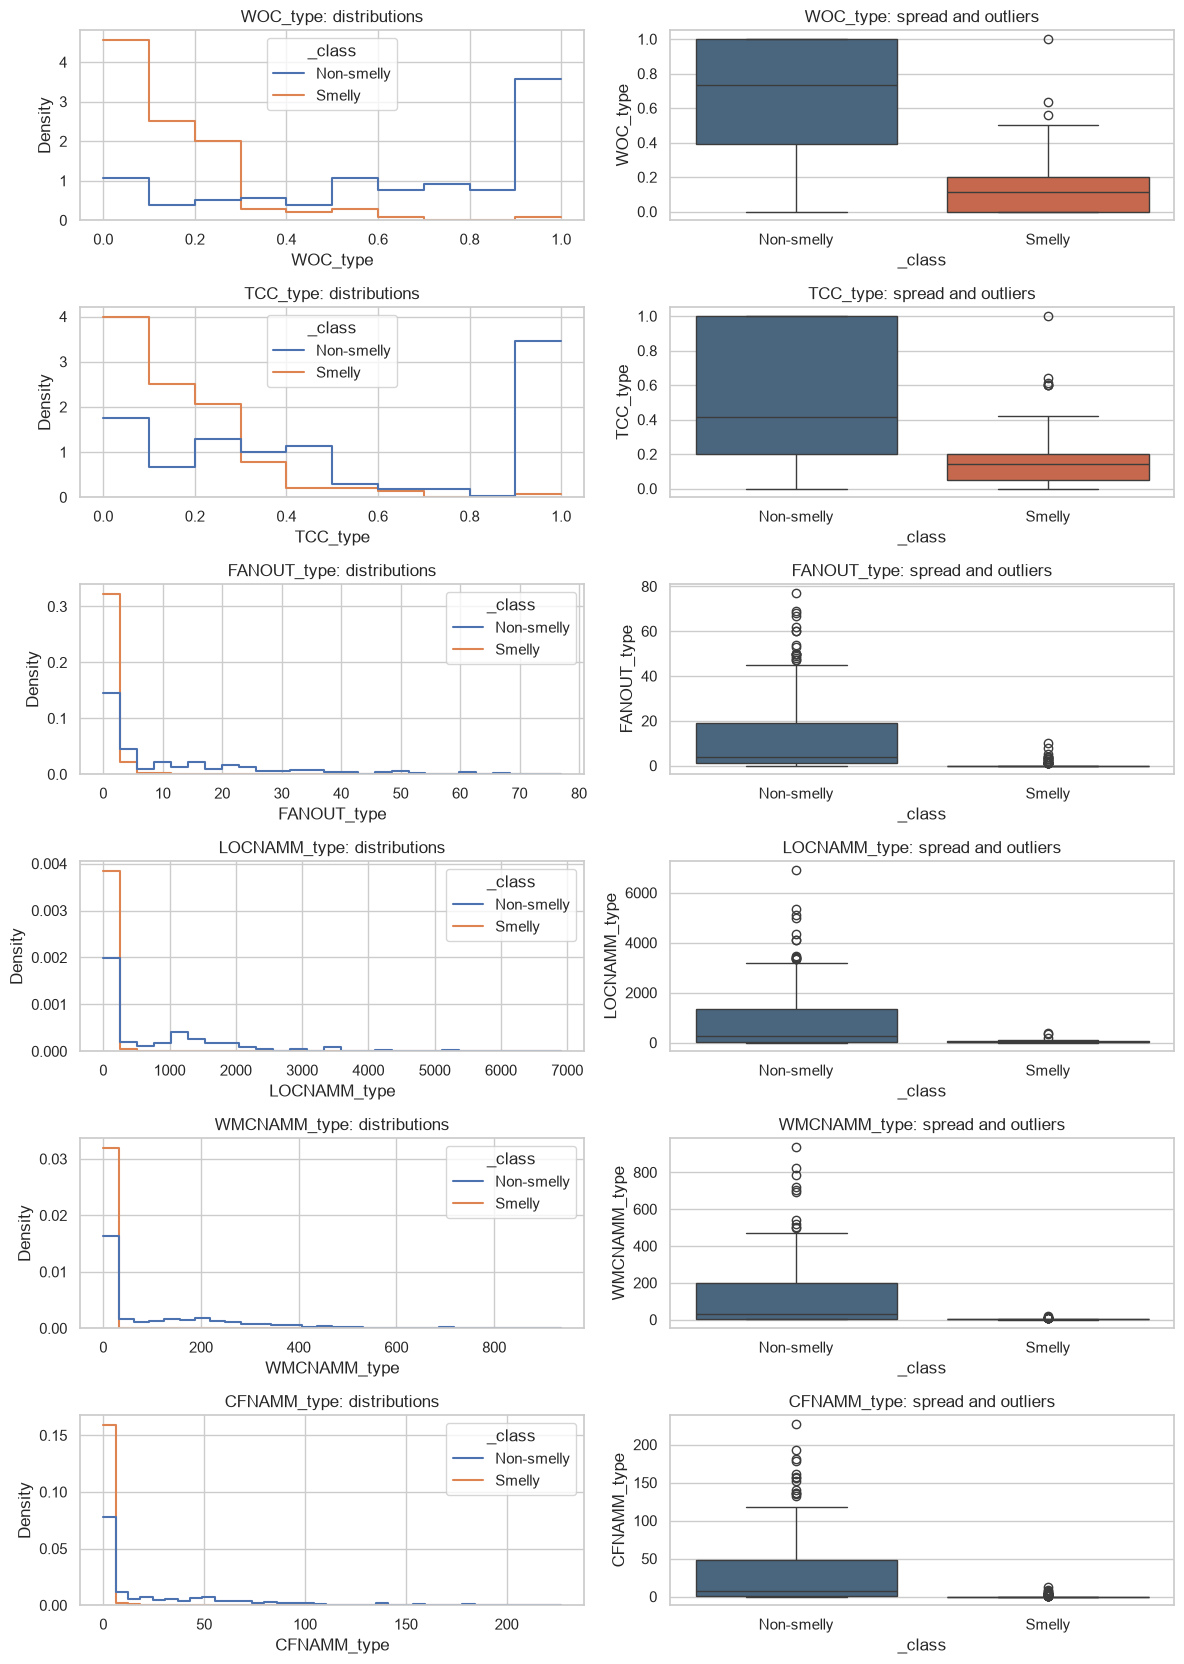

WOC_type: median clean=0.733, smelly=0.111; skew clean=-0.60, smelly=2.03; IQRs do not overlap; observed ranges clean=[0, 1], smelly=[0, 1].
TCC_type: median clean=0.414, smelly=0.143; skew clean=0.16, smelly=2.08; IQRs overlap; observed ranges clean=[0, 1], smelly=[0, 1].
FANOUT_type: median clean=4, smelly=0; skew clean=1.66, smelly=4.04; IQRs do not overlap; observed ranges clean=[0, 77], smelly=[0, 10].
LOCNAMM_type: median clean=248, smelly=29.5; skew clean=2.03, smelly=4.03; IQRs overlap; observed ranges clean=[3, 6.91e+03], smelly=[0, 380].
WMCNAMM_type: median clean=29.5, smelly=1; skew clean=1.96, smelly=2.38; IQRs do not overlap; observed ranges clean=[1, 937], smelly=[0, 18].
CFNAMM_type: median clean=7, smelly=0; skew clean=1.91, smelly=4.01; IQRs do not overlap; observed ranges clean=[0, 227], smelly=[0, 13].
Interpretation: use the reported medians, skew, IQR overlap, and outliers to describe these samples; even separated IQRs are not universal smell thresholds.

Feature 

FDP_method                                     ATFD_method          \
                count   mean median    std min max   skew       count    mean   
_class                                                                          
Non-smelly        280  0.371    0.0  0.756   0   4  2.425         280   0.814   
Smelly            140  4.350    4.0  2.658   1  14  1.188         140  15.964   

                   ... FANOUT_method            CFNAMM_method                 \
           median  ...           min max   skew         count    mean median   
_class             ...                                                         
Non-smelly    0.0  ...             0  21  3.358           280   2.029    1.0   
Smelly       12.0  ...             0  30  1.300           140  12.029    9.0   

                                   
               std min max   skew  
_class                             
Non-smelly   3.640   0  22  2.901  
Smelly      10.945   0  70  2.056  

[2 rows x 42 columns]

Largest absolute standardized mean differences (descriptive): {'FDP_method': 1.59, 'ATFD_method': 1.47, 'CINT_method': 1.36, 'NOAV_method': 1.32, 'FANOUT_method': 1.27, 'CFNAMM_method': 1.19}


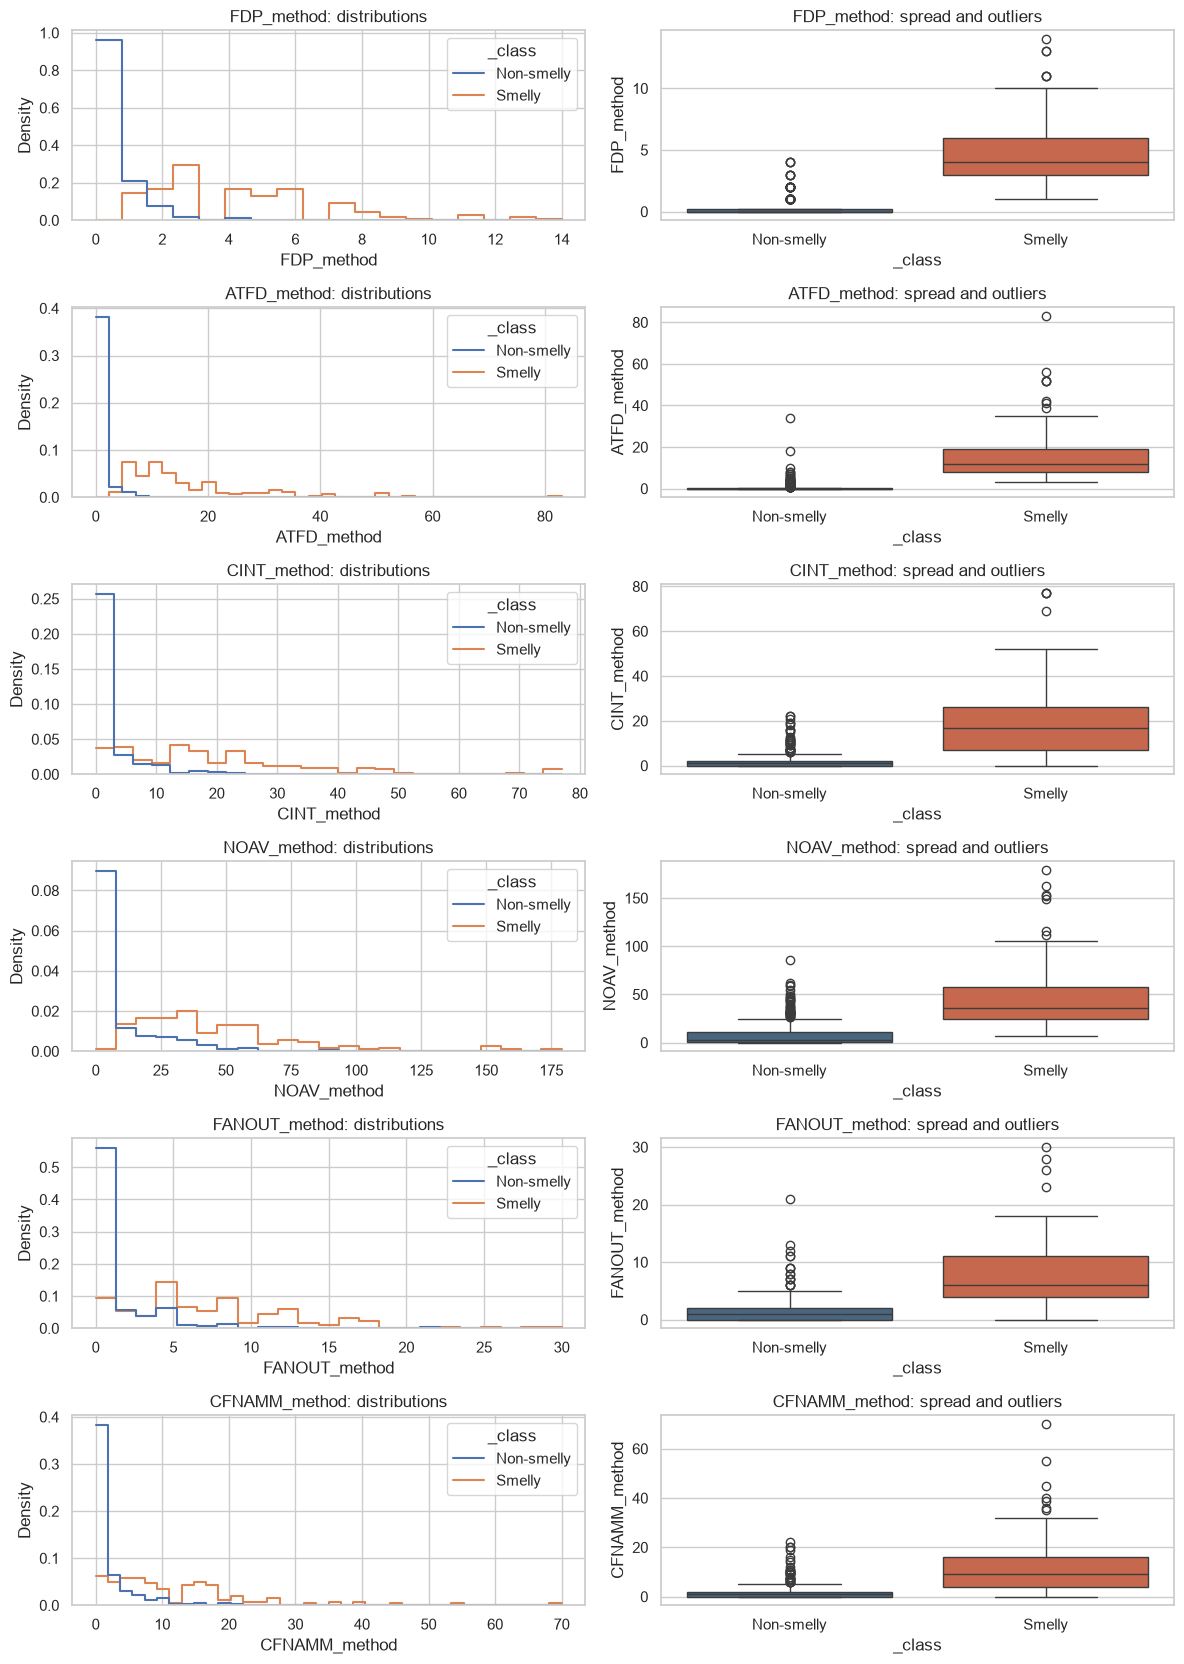

FDP_method: median clean=0, smelly=4; skew clean=2.43, smelly=1.19; IQRs do not overlap; observed ranges clean=[0, 4], smelly=[1, 14].
ATFD_method: median clean=0, smelly=12; skew clean=8.11, smelly=2.26; IQRs do not overlap; observed ranges clean=[0, 34], smelly=[3, 83].
CINT_method: median clean=1, smelly=17; skew clean=2.64, smelly=1.48; IQRs do not overlap; observed ranges clean=[0, 22], smelly=[0, 77].
NOAV_method: median clean=3, smelly=35.5; skew clean=2.17, smelly=1.73; IQRs do not overlap; observed ranges clean=[0, 86], smelly=[7, 179].
FANOUT_method: median clean=1, smelly=6; skew clean=3.36, smelly=1.30; IQRs do not overlap; observed ranges clean=[0, 21], smelly=[0, 30].
CFNAMM_method: median clean=1, smelly=9; skew clean=2.90, smelly=2.06; IQRs do not overlap; observed ranges clean=[0, 22], smelly=[0, 70].
Interpretation: use the reported medians, skew, IQR overlap, and outliers to describe these samples; even separated IQRs are not universal smell thresholds.


In [30]:
distribution_summaries = {}
for name, item in data.items():
    X, y = item["X"], item["y"]
    summary = X.assign(_class=y.map({0: "Non-smelly", 1: "Smelly"})).groupby("_class").agg(["count", "mean", "median", "std", "min", "max", "skew"]).round(3)
    distribution_summaries[name] = summary
    effect = (X[y.eq(1)].mean() - X[y.eq(0)].mean()) / X.std(ddof=1).replace(0, np.nan)
    selected = effect.abs().sort_values(ascending=False).head(min(TOP_METRICS_TO_PLOT, X.shape[1])).index.tolist()
    print(f"\n{name}: class-wise metric summary (count, mean, median, std, min, max, skew)")
    display(summary.loc[:, pd.IndexSlice[selected, :]])
    print("Largest absolute standardized mean differences (descriptive):", {m: round(float(effect[m]), 2) for m in selected})
    plot_frame = X[selected].assign(_class=y.map({0: "Non-smelly", 1: "Smelly"}))
    fig, axes = plt.subplots(len(selected), 2, figsize=(12, max(3.0, 2.8 * len(selected))), squeeze=False)
    for row, metric in enumerate(selected):
        sns.histplot(data=plot_frame, x=metric, hue="_class", stat="density", common_norm=False, element="step", fill=False, ax=axes[row, 0])
        axes[row, 0].set_title(f"{metric}: distributions")
        sns.boxplot(data=plot_frame, x="_class", y=metric, order=["Non-smelly", "Smelly"], hue="_class", ax=axes[row, 1], palette={"Non-smelly": "#416788", "Smelly": "#d95d39"}, legend=False)
        axes[row, 1].set_title(f"{metric}: spread and outliers")
    plt.tight_layout(); plt.show()
    for metric in selected:
        clean = X.loc[y.eq(0), metric].dropna()
        smelly = X.loc[y.eq(1), metric].dropna()
        clean_iqr = clean.quantile([0.25, 0.75])
        smelly_iqr = smelly.quantile([0.25, 0.75])
        overlap = max(clean_iqr.iloc[0], smelly_iqr.iloc[0]) <= min(clean_iqr.iloc[1], smelly_iqr.iloc[1])
        central_ranges = "overlap" if overlap else "do not overlap"
        print(
            f"{metric}: median clean={clean.median():.3g}, smelly={smelly.median():.3g}; "
            f"skew clean={clean.skew():.2f}, smelly={smelly.skew():.2f}; "
            f"IQRs {central_ranges}; observed ranges clean=[{clean.min():.3g}, {clean.max():.3g}], "
            f"smelly=[{smelly.min():.3g}, {smelly.max():.3g}]."
        )
    print("Interpretation: use the reported medians, skew, IQR overlap, and outliers to describe these samples; even separated IQRs are not universal smell thresholds.")

## 4. Correlation analysis
Spearman correlation captures monotonic relationships and is less sensitive than Pearson correlation to a few extreme values. Strong metric correlations can mean multiple predictors repeatedly encode a shared property (such as size or complexity). Correlation alone is not evidence of bias; connect it to label-specific distributions, dataset construction, and model behavior.


Data Class: feature correlation matrix (Spearman)


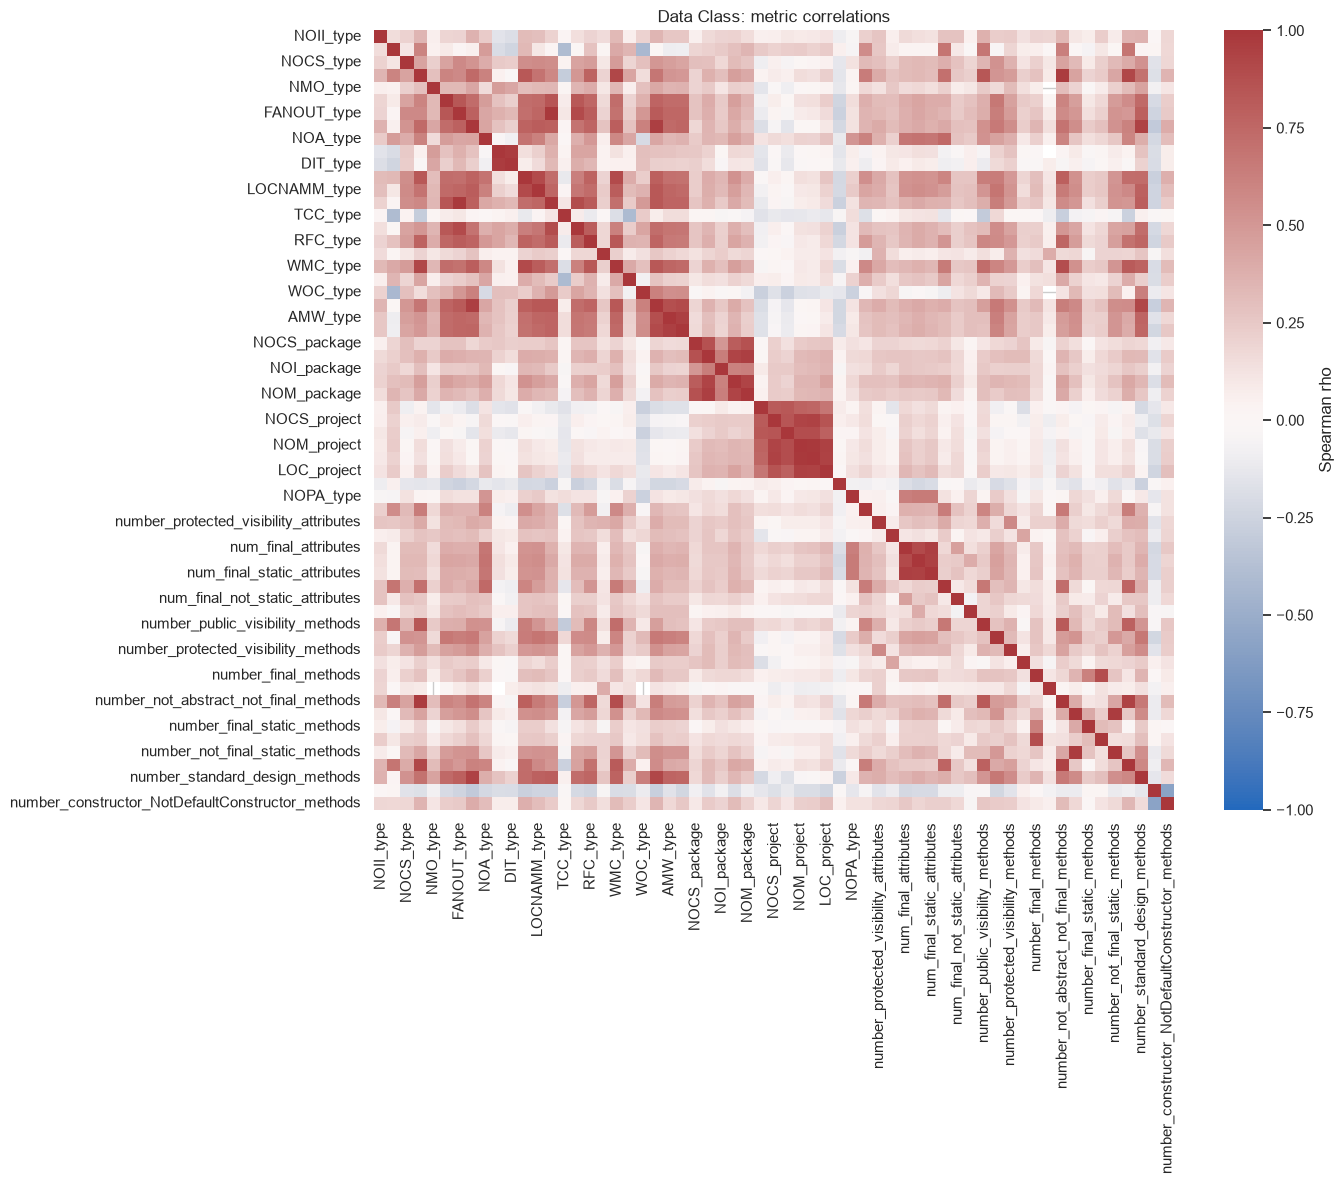

Pairs with |rho| >= 0.85:


,,Spearman rho,abs_rho
NOM_project,NOMNAMM_project,0.992047,0.992047
FANOUT_type,CFNAMM_type,0.984548,0.984548
NOM_type,number_not_abstract_not_final_methods,0.973909,0.973909
number_static_methods,number_not_final_static_methods,0.971779,0.971779
NIM_type,DIT_type,0.971690,0.971690
NOMNAMM_package,NOM_package,0.959118,0.959118
AMW_type,AMWNAMM_type,0.958044,0.958044
num_final_attributes,num_final_static_attributes,0.957508,0.957508
NOMNAMM_type,WMCNAMM_type,0.956822,0.956822
NOM_project,LOC_project,0.950154,0.950154


Interpretation: name related metric groups, then check whether each group also shifts by class. Redundant size proxies can amplify a dataset-specific labeling rule.

Feature Envy: feature correlation matrix (Spearman)


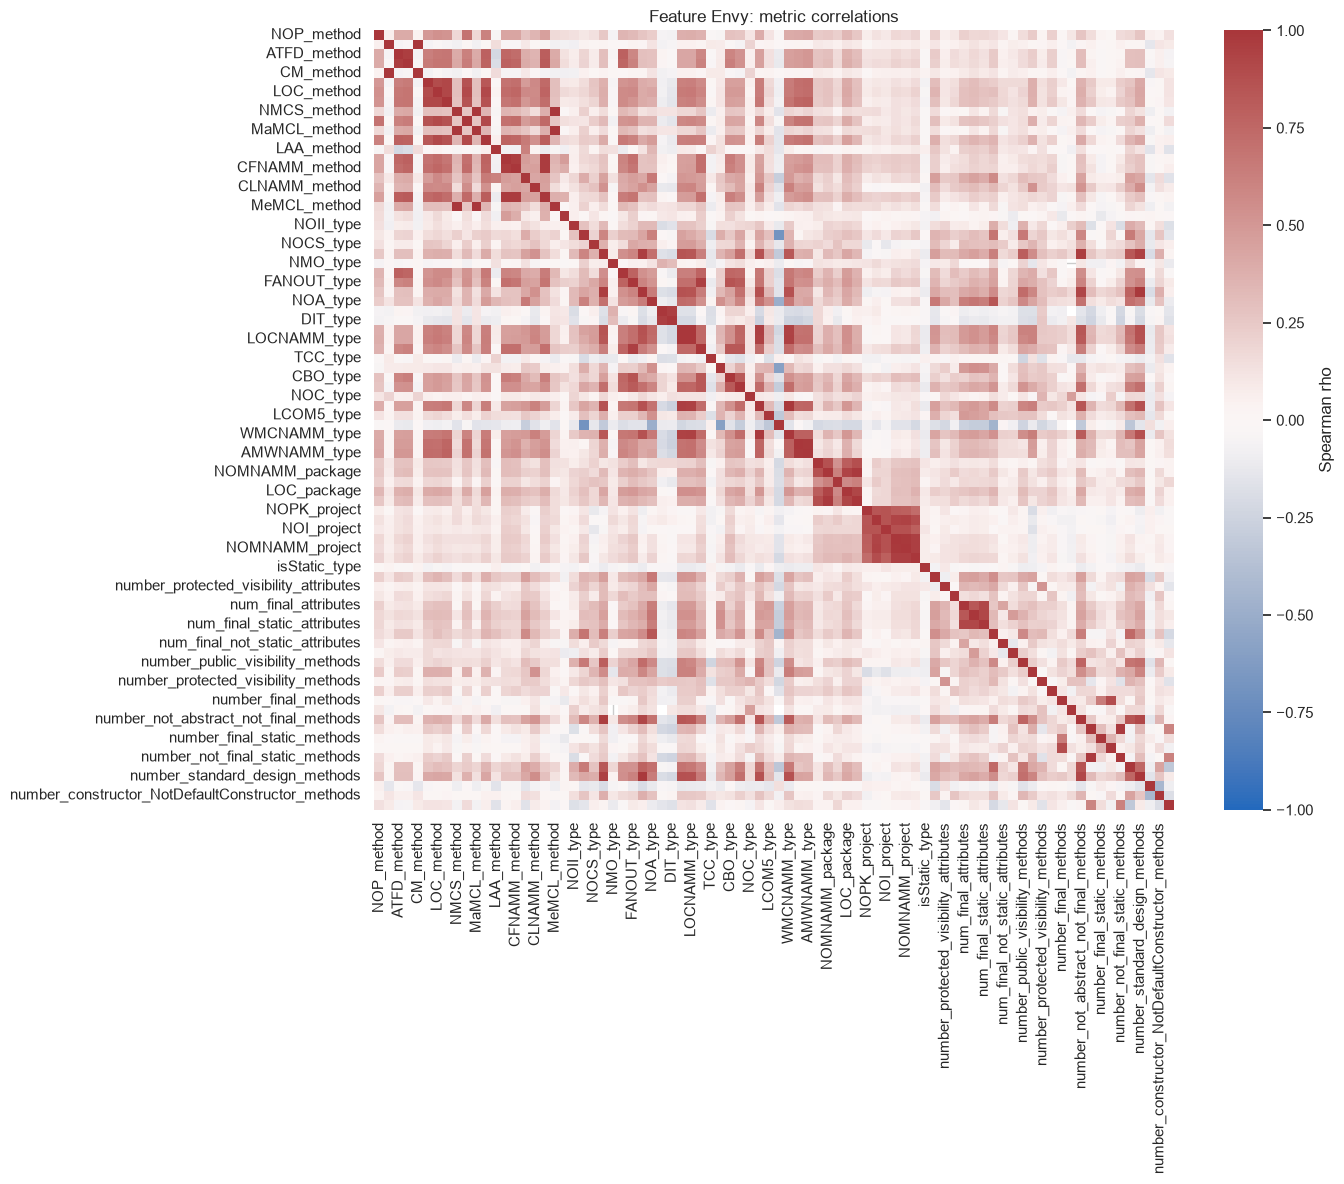

Pairs with |rho| >= 0.85:


Spearman rho  \
MaMCL_method                          MeMCL_method                             0.999666   
NMCS_method                           MaMCL_method                             0.998877   
                                      MeMCL_method                             0.998572   
LOC_type                              LOCNAMM_type                             0.996681   
CC_method                             CM_method                                0.995716   
...                                                                                 ...   
NOCS_project                          NOI_project                              0.856568   
FANOUT_type                           CBO_type                                 0.855855   
number_not_abstract_not_final_methods number_not_final_not_static_methods      0.855248   
NOPK_project                          NOI_project                              0.854339   
                                      NOCS_project                             0.851524   

                                                                            abs_rho  
MaMCL_method                          MeMCL_method                         0.999666  
NMCS_method                           MaMCL_method                         0.998877  
                                      MeMCL_method                         0.998572  
LOC_type                              LOCNAMM_type                         0.996681  
CC_method                             CM_method                            0.995716  
...                                                                             ...  
NOCS_project                          NOI_project                          0.856568  
FANOUT_type                           CBO_type                             0.855855  
number_not_abstract_not_final_methods number_not_final_not_static_methods  0.855248  
NOPK_project                          NOI_project                          0.854339  
                                      NOCS_project                         0.851524  

[64 rows x 2 columns]

Interpretation: name related metric groups, then check whether each group also shifts by class. Redundant size proxies can amplify a dataset-specific labeling rule.


In [31]:
correlations = {}
for name, item in data.items():
    corr = item["X"].corr(method="spearman")
    correlations[name] = corr
    upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
    pairs = (upper.stack().rename("Spearman rho").to_frame()
             .assign(abs_rho=lambda table: table["Spearman rho"].abs())
             .query("abs_rho >= @CORRELATION_THRESHOLD")
             .sort_values("abs_rho", ascending=False))
    print(f"\n{name}: feature correlation matrix (Spearman)")
    fig, ax = plt.subplots(figsize=(min(14, max(7, 0.55 * len(corr.columns))), min(12, max(6, 0.5 * len(corr.columns)))))
    sns.heatmap(corr, cmap="vlag", center=0, vmin=-1, vmax=1, ax=ax, cbar_kws={"label": "Spearman rho"})
    ax.set_title(f"{name}: metric correlations"); plt.tight_layout(); plt.show()
    print(f"Pairs with |rho| >= {CORRELATION_THRESHOLD}:")
    display(pairs if not pairs.empty else pd.DataFrame(columns=["Spearman rho", "abs_rho"]))
    print("Interpretation: name related metric groups, then check whether each group also shifts by class. Redundant size proxies can amplify a dataset-specific labeling rule.")

## 5. Model training and evaluation
Exact duplicate metric/label rows are excluded from modeling. A stratified five-fold group split holds out entire projects for the final test; project identifiers are never predictors. Stratified group cross-validation compares the Decision Tree and class-weighted Random Forest using training projects only. Median imputation is fitted inside each pipeline and each CV fold. Precision, recall, F1, balanced accuracy, and confusion matrices are reported for the positive class **smelly (1)**. A single held-out project fold is informative but not a substitute for external validation across new datasets or labeling protocols.


Data Class: excluding 2 exact metric/label duplicates from model evaluation
Train: 330 rows / 61 projects; test: 88 rows / 13 projects
Test class counts: {'Non-smelly': 60, 'Smelly': 28}
Decision Tree held-out project metrics: {'Precision': 0.966, 'Recall': 1.0, 'F1': 0.982, 'Balanced accuracy': 0.992}


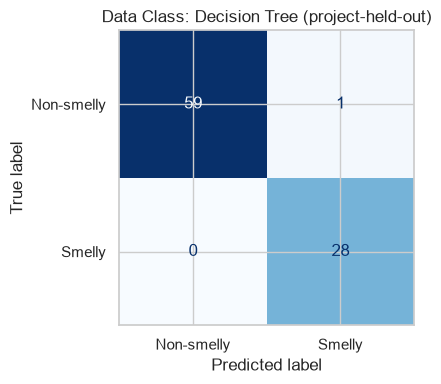

Random Forest held-out project metrics: {'Precision': 1.0, 'Recall': 1.0, 'F1': 1.0, 'Balanced accuracy': 1.0}


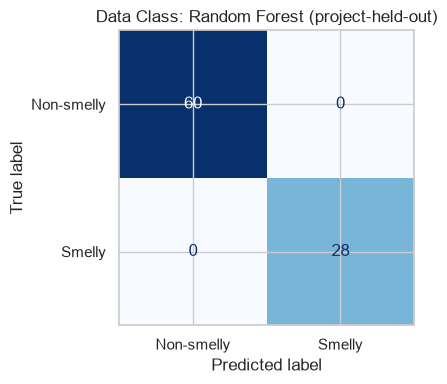


Feature Envy: excluding 13 exact metric/label duplicates from model evaluation
Train: 322 rows / 57 projects; test: 85 rows / 17 projects
Test class counts: {'Non-smelly': 56, 'Smelly': 29}
Decision Tree held-out project metrics: {'Precision': 0.963, 'Recall': 0.897, 'F1': 0.929, 'Balanced accuracy': 0.939}


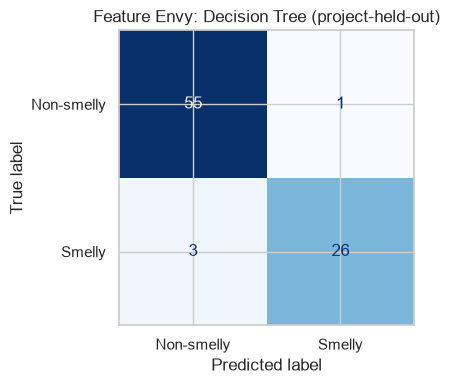

Random Forest held-out project metrics: {'Precision': 1.0, 'Recall': 1.0, 'F1': 1.0, 'Balanced accuracy': 1.0}


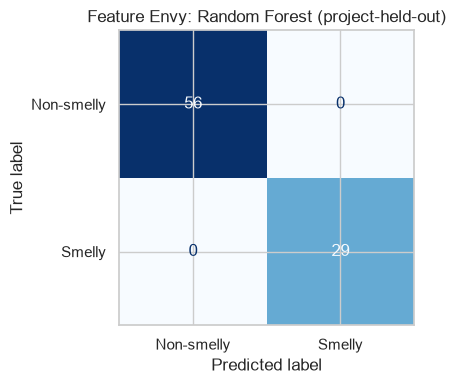

Training-only project-grouped CV results:


,Dataset,Model,CV precision mean,CV recall mean,CV F1 mean,CV F1 std,CV balanced accuracy mean
0,Data Class,Decision Tree,0.929,0.981,0.953,0.030,0.970
1,Data Class,Random Forest,0.955,0.973,0.962,0.039,0.973
2,Feature Envy,Decision Tree,0.917,0.819,0.862,0.079,0.891
3,Feature Envy,Random Forest,0.918,0.964,0.939,0.045,0.958


Held-out project test results (positive class: smelly):


,Dataset,Model,Precision,Recall,F1,Balanced accuracy
0,Data Class,Decision Tree,0.966,1.000,0.982,0.992
1,Data Class,Random Forest,1.000,1.000,1.000,1.000
2,Feature Envy,Decision Tree,0.963,0.897,0.929,0.939
3,Feature Envy,Random Forest,1.000,1.000,1.000,1.000


In [32]:
SCORING = {
    "precision": "precision", "recall": "recall",
    "f1": "f1", "balanced_accuracy": "balanced_accuracy",
}
MODEL_FACTORIES = {
    "Decision Tree": lambda: DecisionTreeClassifier(class_weight="balanced", random_state=RANDOM_STATE),
    "Random Forest": lambda: RandomForestClassifier(n_estimators=300, class_weight="balanced", random_state=RANDOM_STATE, n_jobs=-1),
}

def make_pipeline(features):
    numeric = Pipeline([("imputer", SimpleImputer(strategy="median"))])
    prep = ColumnTransformer([("numeric", numeric, features)], remainder="drop")
    return Pipeline([("preprocess", prep), ("classifier", None)])

def build_model(features, factory):
    pipeline = make_pipeline(features)
    pipeline.set_params(classifier=factory())
    return pipeline

cv_results = []
test_results = []
test_predictions = {}
splits = {}
for name, item in data.items():
    X, y, groups = item["X"], item["y"], item["groups"]
    labeled_metrics = X.assign(_target=y)
    unique_rows = ~labeled_metrics.duplicated()
    removed_duplicates = int((~unique_rows).sum())
    X, y, groups = X.loc[unique_rows], y.loc[unique_rows], groups.loc[unique_rows]
    print(f"\n{name}: excluding {removed_duplicates} exact metric/label duplicates from model evaluation")

    outer_cv = StratifiedGroupKFold(n_splits=round(1 / TEST_SIZE), shuffle=True, random_state=RANDOM_STATE)
    train_indices, test_indices = next(outer_cv.split(X, y, groups))
    X_train, X_test = X.iloc[train_indices], X.iloc[test_indices]
    y_train, y_test = y.iloc[train_indices], y.iloc[test_indices]
    groups_train, groups_test = groups.iloc[train_indices], groups.iloc[test_indices]
    if set(groups_train).intersection(groups_test):
        raise RuntimeError(f"{name}: project groups leaked across train and test.")
    print(f"Train: {len(X_train)} rows / {groups_train.nunique()} projects; test: {len(X_test)} rows / {groups_test.nunique()} projects")
    print("Test class counts:", y_test.value_counts().reindex([0, 1], fill_value=0).rename(index={0: "Non-smelly", 1: "Smelly"}).to_dict())
    splits[name] = (X_train, X_test, y_train, y_test, groups_train, groups_test)
    cv = StratifiedGroupKFold(n_splits=min(CV_FOLDS, groups_train.nunique()), shuffle=True, random_state=RANDOM_STATE)

    for model_name, factory in MODEL_FACTORIES.items():
        features = X_train.columns.tolist()
        model = build_model(features, factory)
        scores = cross_validate(
            model, X_train, y_train, groups=groups_train, cv=cv,
            scoring=SCORING, n_jobs=1, error_score="raise",
        )
        model.fit(X_train, y_train)
        prediction = model.predict(X_test)
        test_predictions[(name, model_name)] = prediction
        cv_results.append({
            "Dataset": name, "Model": model_name,
            "CV precision mean": scores["test_precision"].mean(),
            "CV recall mean": scores["test_recall"].mean(),
            "CV F1 mean": scores["test_f1"].mean(),
            "CV F1 std": scores["test_f1"].std(),
            "CV balanced accuracy mean": scores["test_balanced_accuracy"].mean(),
        })
        result = {
            "Dataset": name, "Model": model_name,
            "Precision": precision_score(y_test, prediction, zero_division=0),
            "Recall": recall_score(y_test, prediction, zero_division=0),
            "F1": f1_score(y_test, prediction, zero_division=0),
            "Balanced accuracy": balanced_accuracy_score(y_test, prediction),
        }
        test_results.append(result)
        print(f"{model_name} held-out project metrics:", {key: round(value, 3) for key, value in result.items() if isinstance(value, float)})
        fig, ax = plt.subplots(figsize=(4.5, 4))
        ConfusionMatrixDisplay.from_predictions(
            y_test, prediction, display_labels=["Non-smelly", "Smelly"],
            cmap="Blues", colorbar=False, ax=ax,
        )
        ax.set_title(f"{name}: {model_name} (project-held-out)")
        plt.tight_layout(); plt.show()

print("Training-only project-grouped CV results:")
display(pd.DataFrame(cv_results).round(3))
print("Held-out project test results (positive class: smelly):")
display(pd.DataFrame(test_results).round(3))

## 6. Additional experiment: remove size-related metrics
This ablation tests whether grouped-CV and project-held-out performance depends on LOC, method/class counts, or related size proxies. The feature-name pattern is visible and deliberately excludes `ATFD`, which is a Feature Envy metric rather than a generic size measure. Treat the ablation as a sensitivity check, not a causal test: correlated predictors may substitute for removed features.

In [33]:
SIZE_PATTERN = re.compile(r"(^|_)(LOC|WMC|NOM|NOA|NOMNAMM|AMW|NPM|NPA|TLOC|LLOC)(_|$)", re.I)
ablation_rows = []
for name, item in data.items():
    X_train, X_test, y_train, y_test, groups_train, groups_test = splits[name]
    size_features = [column for column in X_train.columns if SIZE_PATTERN.search(str(column))]
    reduced_features = [column for column in X_train.columns if column not in size_features]
    print(f"\n{name}: size-related columns removed: {size_features}")
    if not size_features or not reduced_features:
        print("Ablation skipped because no suitable size-feature subset was found.")
        continue
    cv = StratifiedGroupKFold(n_splits=min(CV_FOLDS, groups_train.nunique()), shuffle=True, random_state=RANDOM_STATE)
    for model_name, factory in MODEL_FACTORIES.items():
        for setting, features in [("All metrics", X_train.columns.tolist()), ("Without size metrics", reduced_features)]:
            model = build_model(features, factory)
            scores = cross_validate(
                model, X_train[features], y_train, groups=groups_train, cv=cv,
                scoring=SCORING, n_jobs=1, error_score="raise",
            )
            model.fit(X_train[features], y_train)
            prediction = model.predict(X_test[features])
            ablation_rows.append({
                "Dataset": name, "Model": model_name, "Features": setting,
                "CV F1 mean": scores["test_f1"].mean(),
                "CV balanced accuracy mean": scores["test_balanced_accuracy"].mean(),
                "Test F1": f1_score(y_test, prediction, zero_division=0),
                "Test balanced accuracy": balanced_accuracy_score(y_test, prediction),
            })
ablation = pd.DataFrame(ablation_rows)
print("Grouped-CV and project-held-out size-feature ablation:")
display(ablation.round(3))


Data Class: size-related columns removed: ['NOM_type', 'NOMNAMM_type', 'NOA_type', 'LOC_type', 'WMC_type', 'AMW_type', 'NOMNAMM_package', 'LOC_package', 'NOM_package', 'NOM_project', 'NOMNAMM_project', 'LOC_project']

Feature Envy: size-related columns removed: ['LOC_method', 'NOM_type', 'NOMNAMM_type', 'NOA_type', 'LOC_type', 'WMC_type', 'AMW_type', 'NOMNAMM_package', 'LOC_package', 'NOM_package', 'NOM_project', 'NOMNAMM_project', 'LOC_project']
Grouped-CV and project-held-out size-feature ablation:


,Dataset,Model,Features,CV F1 mean,CV balanced accuracy mean,Test F1,Test balanced accuracy
0,Data Class,Decision Tree,All metrics,0.953,0.970,0.982,0.992
1,Data Class,Decision Tree,Without size metrics,0.953,0.973,0.982,0.992
2,Data Class,Random Forest,All metrics,0.962,0.973,1.000,1.000
3,Data Class,Random Forest,Without size metrics,0.976,0.987,0.982,0.992
4,Feature Envy,Decision Tree,All metrics,0.862,0.891,0.929,0.939
5,Feature Envy,Decision Tree,Without size metrics,0.861,0.891,0.947,0.957
6,Feature Envy,Random Forest,All metrics,0.939,0.958,1.000,1.000
7,Feature Envy,Random Forest,Without size metrics,0.933,0.951,1.000,1.000


## 7. Evidence-based interpretation

**Sample composition and quality.** Both datasets contain 420 rows: 140 smelly (33.3%) and 280 non-smelly (66.7%). Data Class has 75 missing feature cells and 2 duplicate metric/label rows; Feature Envy has 92 missing cells, 13 such duplicate rows, and one near-constant feature. Missing numeric values are imputed within each training pipeline. The 1:2 sample ratio is not a prevalence estimate.

**Metric distributions.** The official [metric definitions](https://essere.disco.unimib.it/wp-content/uploads/sites/71/2019/04/metric-definitions.pdf) define WOC as functional public methods divided by public members and TCC as a normalized cohesion measure. For Data Class, the non-smelly median WOC is 0.733 versus 0.111 for smelly instances, and their IQRs do not overlap; TCC medians are 0.414 versus 0.143, with overlapping IQRs. For Feature Envy, ATFD counts attributes accessed from unrelated classes, FDP counts the foreign-data provider classes, CINT counts distinct operations called, and NOAV counts variables accessed. All six plotted metrics have non-overlapping IQRs in this sample: for example, FDP medians are 0 versus 4, and ATFD medians are 0 versus 12. The overall observed ranges still overlap, and count metrics are strongly right-skewed with outliers. These are strong sample-level associations, not universal cutoffs.

**Correlations and model evidence.** Data Class includes `NOM_project`/`NOMNAMM_project` at Spearman rho 0.992 and `FANOUT_type`/`CFNAMM_type` at 0.985. Feature Envy includes `MaMCL_method`/`MeMCL_method` at 0.9997 and `LOC_type`/`LOCNAMM_type` at 0.9967. The random forest achieved held-out-project F1 of 1.000 on both datasets, while its grouped-CV F1 was 0.962 for Data Class and 0.939 for Feature Envy. Removing the selected size-related metrics changed scores only modestly; therefore, this experiment does not show that size alone explains performance. Other metrics may encode similar information or align closely with the archive's labels.

**Limits.** The test projects were held out from training, but they still come from the same archive, metric collection, and labeling process. Perfect test scores on one grouped fold do not demonstrate deployment performance on new projects or another labeling protocol. The evidence supports strong metric-label associations in these samples; it cannot establish causal mechanisms, real-world prevalence, or broad generalizability.